In [1]:
import sys
sys.path.append('..')

from Pretrain import pretrain
from torch import nn
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import json

from model_stuff import Predictor
from Rollout2 import _sample_transitions, train_rollout
from SingleModel import SingleModel


best  = {
  "lag": 150,
  "n_pretrain_epochs": 20,
  "lr_pretrain": 0.001962635090084424,
  "train_horizon": 120,
  "train_steps": 200,
  "lr_rollout": 9.945405230349677e-05,
  "transition_prob": 0.7,
  "dropout": 0.027353153688391404,
  "loss": "mse",
  "transition_config": "200_12"
}

In [2]:
X_df = pd.read_csv('../../data/CombinedDatasetLongUnsmooth.csv')
X_df = X_df.drop(columns=['AMOC']).rename(columns={'AMOC_40N': 'AMOC'})
model_vars   = ['AMOC', 'SFWF', 'PD_200m']
feature_cols = target_cols = model_vars
train_cut_1, train_cut_2 = 12500, 18500
train_idx = list(range(train_cut_1)) + list(range(train_cut_2, len(X_df)))

y_scalers = {}
X_scaled  = X_df[model_vars].copy().astype(float)
for var in model_vars:
    sc = StandardScaler().fit(X_df[var].values[train_idx].reshape(-1, 1))
    X_scaled[var] = sc.transform(X_df[var].values.reshape(-1, 1))
    y_scalers[var] = sc


x_scaler = StandardScaler().fit(X_df[feature_cols].values[train_idx])

In [56]:
off_to_on_threshold = 10
on_to_off_threshold = 6
search_ahead = 50
lag = 150
on_to_off1, off_to_on1, normal1 = _sample_transitions(X_df[:train_cut_1], 
                                        off_to_on_threshold=off_to_on_threshold,
                                        on_to_off_threshold=on_to_off_threshold,
                                        search_ahead=search_ahead, 
                                        lag=lag)
on_to_off2, off_to_on2, normal2 = _sample_transitions(X_df[train_cut_2:], 
                                        off_to_on_threshold=off_to_on_threshold,
                                        on_to_off_threshold=on_to_off_threshold,
                                        search_ahead=search_ahead, 
                                        lag=lag)

transitions = off_to_on1 + [w + train_cut_2 for w in off_to_on2] + on_to_off1 + [w + train_cut_2 for w in on_to_off2]
normal      = normal1 + [w + train_cut_2 for w in normal2]
print(f"off_to_on1: {len(off_to_on1)}, off_to_on2: {len(off_to_on2)}")
print(f"on_to_off1: {len(on_to_off1)}, on_to_off2: {len(on_to_off2)}")

off_to_on1: 155, off_to_on2: 137
on_to_off1: 252, on_to_off2: 90


In [26]:
model = Predictor(n_features=3, hidden_size=64, num_layers=1, dropout=best['dropout'], output_size=3)

pretrain(X_scaled, train_cut_1, train_cut_2, model,
         feature_cols, target_cols,
         lag=150, horizon=1,        
         n_epochs=20, batch_size=64,
         lr=best['lr_pretrain'], loss_fn=nn.MSELoss())

transition_prob = 0.9

train_rollout(X_scaled, transition_prob,
              model, feature_cols, target_cols,
              train_steps=400, lag=150, train_horizon=100, 
              loss_fn=nn.MSELoss(), lr=best['lr_rollout'],
              transitions=transitions, normal=normal)
              
single = SingleModel.from_trained(model, x_scaler, y_scalers)

Epoch 10/20  loss: 0.0326
Epoch 20/20  loss: 0.0319


IndexError: index 75 is out of bounds for axis 0 with size 75

In [27]:
single = SingleModel.from_trained(model, x_scaler, y_scalers)

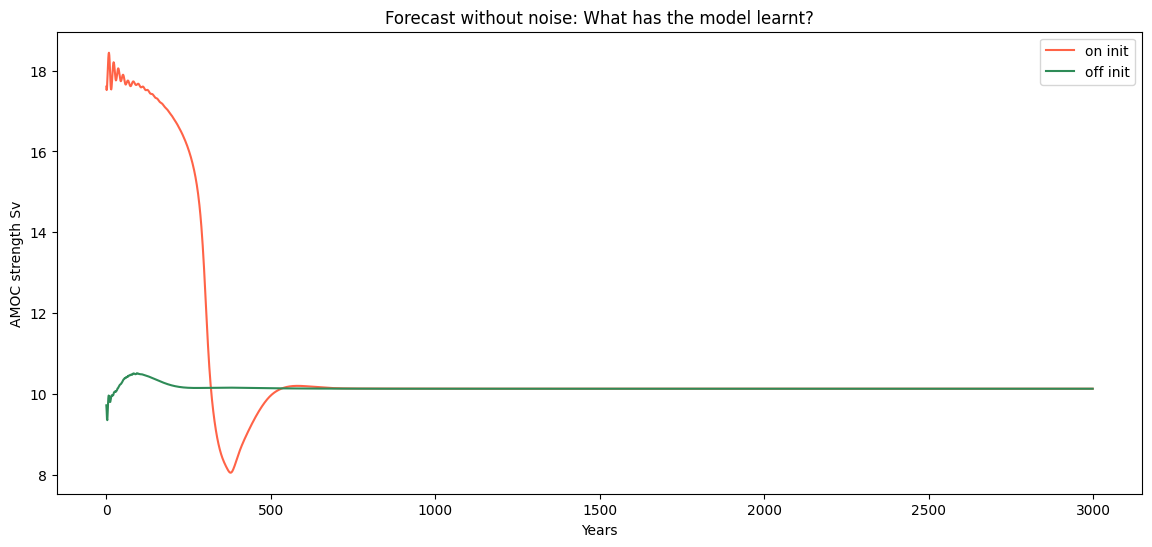

In [28]:
start_idx_off = 5100
start_idx_on = 6600
steps = 3000

preds_on  = single.predict(X_df, start_idx_on, feature_cols, target_cols, lag=100, steps=steps, threshold=14, rho=0.9, k=0.0)
preds_off  = single.predict(X_df, start_idx_off, feature_cols, target_cols, lag=100, steps=steps, threshold=14, rho=0.9, k=0.0)

import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(14,6))

x = np.arange(steps)

plt.plot(x, preds_on['AMOC'], label = 'on init', color = '#FF6347')
plt.plot(x, preds_off['AMOC'], label = 'off init', color = '#2E8B57')
plt.title('Forecast without noise: What has the model learnt?')
plt.xlabel('Years')
plt.ylabel('AMOC strength Sv')
plt.legend()

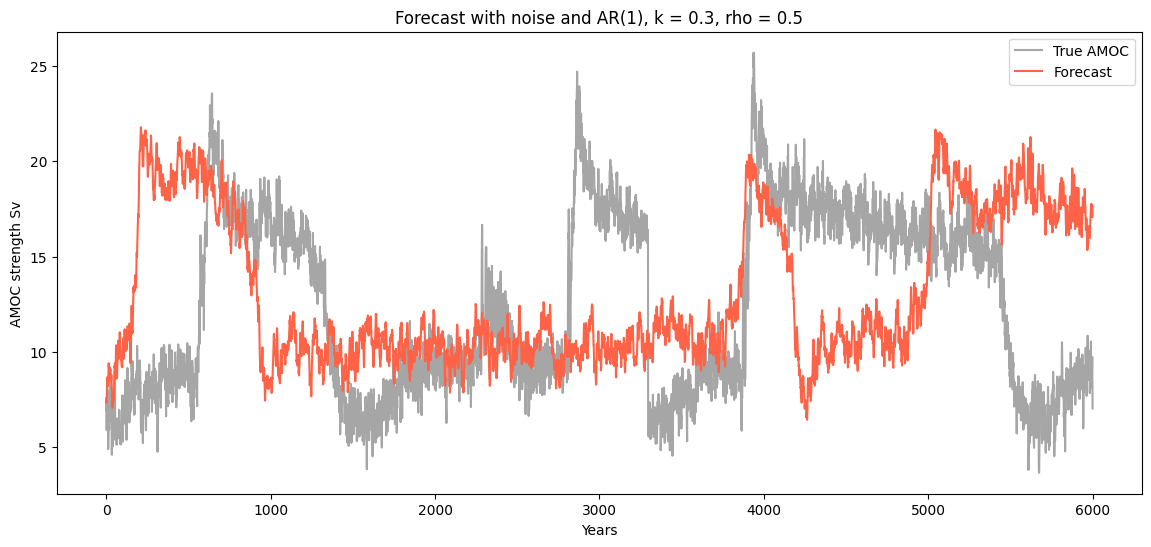

In [31]:
start_idx_on = train_cut_1
steps = train_cut_2 - train_cut_1

preds  = single.predict(X_df, start_idx_on, feature_cols, target_cols, lag=100, steps=steps, threshold=14, rho=0.9, k=0.01)

plt.figure(figsize=(14,6))

x = np.arange(train_cut_2-train_cut_1)

plt.plot(x, X_df['AMOC'][train_cut_1:train_cut_2], label = 'True AMOC', color = 'grey', alpha = 0.7)
plt.plot(x, preds['AMOC'], label = 'Forecast', color = '#FF6347')
plt.title('Forecast with noise and AR(1), k = 0.3, rho = 0.5')
plt.xlabel('Years')
plt.ylabel('AMOC strength Sv')
plt.legend()

In [43]:
off_to_on1[30:]

[1030,
 1031,
 1032,
 1033,
 1034,
 1035,
 1036,
 1037,
 1038,
 1039,
 1040,
 2769,
 2770,
 2771,
 2772,
 2773,
 2774,
 2775,
 2776,
 2777,
 2778,
 2779,
 2780,
 2781,
 2782,
 2783,
 2784,
 2785,
 2786,
 2787,
 6242,
 6243,
 6244,
 6245,
 6246,
 6247,
 6248,
 6249,
 6250,
 6251,
 6252,
 6253,
 6254,
 6255,
 6256,
 6257,
 6258,
 6259,
 6260,
 6261,
 6262,
 6263,
 6264,
 6265,
 6266,
 6267,
 6268,
 6269,
 6270,
 6271,
 8984,
 8985,
 8986,
 8987,
 8988,
 8989,
 8990,
 8991,
 8992,
 8993,
 8994,
 8995,
 8996,
 8997,
 8998,
 8999,
 9000,
 9001,
 9002,
 9003,
 9004,
 9005,
 9006,
 11224,
 11225,
 11226,
 11227,
 11228,
 11229,
 11230,
 11231,
 11232,
 11233,
 11234,
 11235,
 11236,
 11237,
 11238,
 11239,
 11240,
 11241,
 11242,
 11243,
 11244,
 11245,
 11246,
 11247,
 11248,
 11249,
 11250,
 11251,
 11252,
 11253,
 11254,
 11255,
 11256,
 11257,
 11258,
 11259,
 11260,
 11261,
 11262,
 11263,
 11264,
 11266]

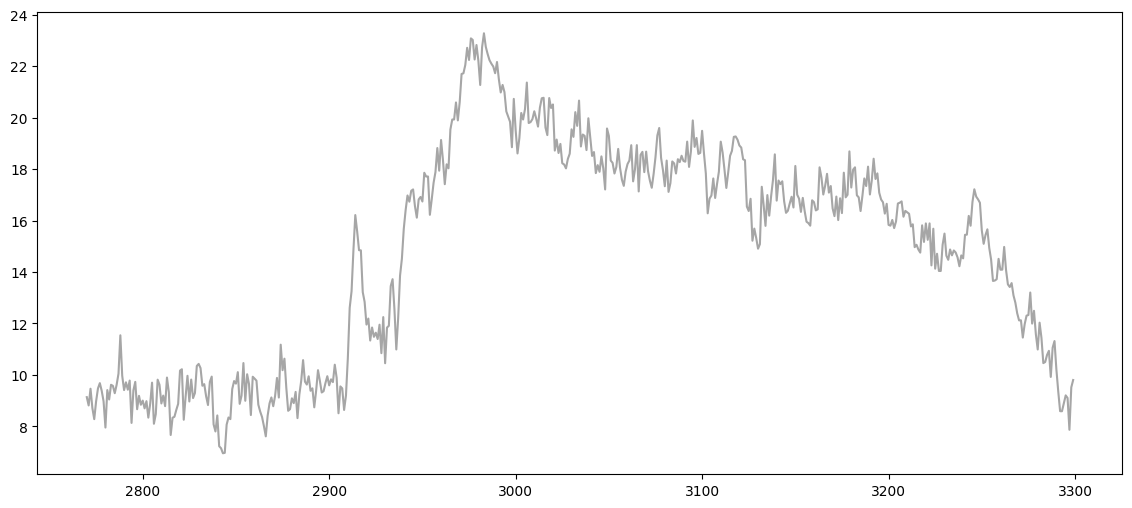

In [47]:
plt.figure(figsize=(14,6))

plt.plot(X_df['AMOC'][2770:3300], label = 'True AMOC', color = 'grey', alpha = 0.7)

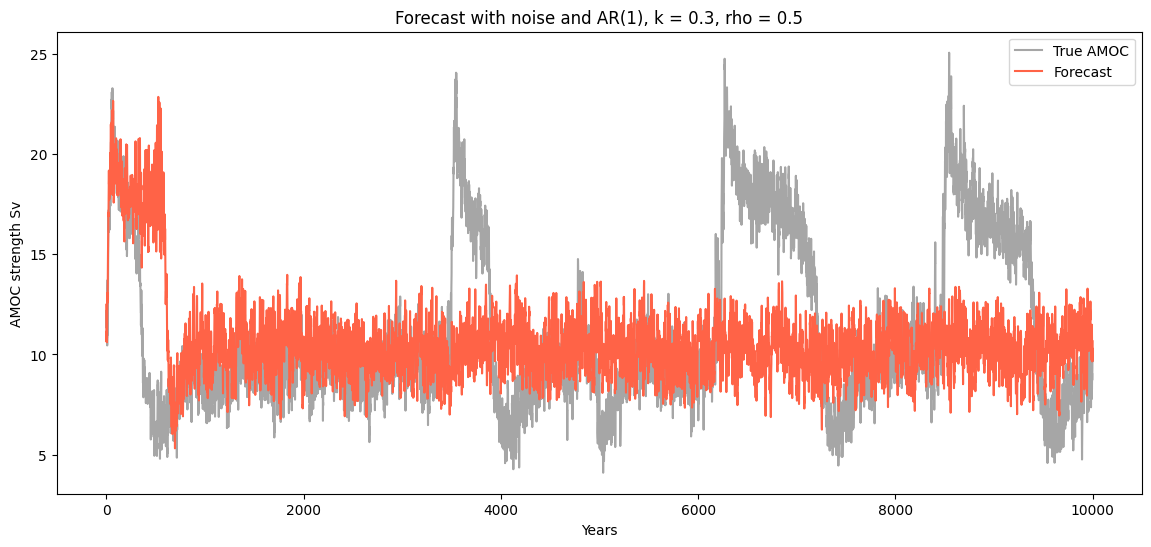

In [55]:
start_idx = 2920
steps = 10000

preds  = single.predict(X_df, start_idx, feature_cols, target_cols, lag=100, steps=steps, threshold=14, rho=0.7, k=0.02)

plt.figure(figsize=(14,6))

x = np.arange(steps)

plt.plot(x, X_df['AMOC'][start_idx:start_idx + steps], label = 'True AMOC', color = 'grey', alpha = 0.7)
plt.plot(x, preds['AMOC'], label = 'Forecast', color = '#FF6347')
plt.title('Forecast with noise and AR(1), k = 0.3, rho = 0.5')
plt.xlabel('Years')
plt.ylabel('AMOC strength Sv')
plt.legend()